<div class="alert alert-block alert-info">
    <h2 align="center"style="color: black;">Machine Learning-based Algorithmic Trading</h2>
    <h3 align="center"style="color: black;">Walk Forward Backtest Experiment</h3>
    <h5 align="center"style="color: black;">Week 5 Day 1</h5>
    <h5 align="center"style="color: black;"><em>Mohammad Talaei</em></h5>
</div>

# Kaggle services and tools

In [1]:
!pip install wandb &> /dev/null
!pip install feature_engine &> /dev/null
!pip install --upgrade pyarrow &> /dev/null
!pip install --upgrade scikit-learn &> /dev/null
!pip install --upgrade xgboost==2.0.3 &> /dev/null

In [2]:
!pip show feature_engine

Name: feature-engine
Version: 1.8.1
Summary: Feature engineering and selection package with Scikit-learn's fit transform functionality
Home-page: http://github.com/feature-engine/feature_engine
Author: Soledad Galli
Author-email: solegalli@protonmail.com
License: BSD 3 clause
Location: /opt/conda/lib/python3.10/site-packages
Requires: numpy, pandas, scikit-learn, scipy, statsmodels
Required-by: 


In [3]:
model_type = 'XGB' #? RF , XGB, 'LGBM'
MANUAL_EXP = True

In [4]:
print(MANUAL_EXP)

True


# Weights & Biase

![ChessUrl](https://docs.wandb.ai/assets/images/wandb_demo_experiments-4797af7fe7236d6c5c42adbdc93deb4c.gif "chess")

Steps:
- Create a W&B account [wandb.ai](https://wandb.ai/)
- Read docs [W&B docs](https://docs.wandb.ai/)
- Install using pip:  `!pip install wandb`
- Get API token [link](https://wandb.ai/authorize)
- Create a secret or an env variable for the token

In [7]:
import wandb
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value = user_secrets.get_secret("wandb_token")
wandb.login(key=secret_value) 

api = wandb.Api()

wandb: Currently logged in as: amirhosseinfarahani (alpha-hunters). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


In [6]:
!wandb login

wandb: Currently logged in as: amirhosseinfarahani (alpha-hunters). Use `wandb login --relogin` to force relogin


# Read functions from the GitHub repo

- GitHub account and repo
- Generate an access token on your GitHub account [Link](https://github.com/settings/tokens)
- Then make a secret or an environment variable to use it

In [8]:
import sys
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
token = user_secrets.get_secret("GITHUB_TOKEN")
!rm -r ./ML-Algotrading-Project &> /dev/null
!git clone https://{token}@github.com/AmirhsFar/ML-Algotrading-Project.git &> /dev/null
!pip install -r ./ML-Algotrading-Project/dataset/requirements.txt
sys.path.append("/kaggle/working/ML-Algotrading-Project")
print('All done')

ERROR: Could not find a version that satisfies the requirement MetaTrader5==5.0.4424 (from versions: none)
ERROR: No matching distribution found for MetaTrader5==5.0.4424
All done


In [9]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from dataset.configs.feature_configs_general import generate_general_config
from dataset.data_crawlers.dukascopy_func import (
    crawl_OHLCV_data_dukascopy
)
from dataset.stage_one_data.history_data_stage_one_func import (
    history_data_stage_one
)
from dataset.realtime_candle.realtime_candle_func import (
    historiy_realtime_candle
)
from dataset.create_features.indicator_func import history_indicator_calculator
from dataset.create_features.realtime_shift_func import history_cndl_shift
from dataset.create_features.create_basic_features_func import (
    history_basic_features,
    history_fe_market_close,
    history_fe_time
)
from dataset.create_features.window_agg_features_func import (
    history_fe_WIN_features
)
from dataset.create_dataset.columns_merge_func import history_columns_merge
# from dataset.data_crawlers.metatrader_func import (
#     crawl_OHLCV_data_metatrader,
# )
from main_func import main
# from forex_MLOps.utils.wandb_utils import read_obj
from ETL import read_data_manual, ETL
# from forex_MLOps.model_ensemble import QuantEnsemble
from utils.wandb_utils import fetch_artifacts, read_tracker_objects, download_wandb_artifact
########### READ DATA MANUALLY #########
# df_all = read_data_manual()
# !tail -n 120 ./forex_MLOps/ETL.py  

# 0. Data Fetching & Preprocessing

## Dukascopy

In [10]:
config_general = generate_general_config()
failed_dates_dict = await crawl_OHLCV_data_dukascopy(
    feature_config = config_general 
)

  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:--> start crawl_OHLCV_data_dukascopy fumc:
  [test run][INFO]:--> number of days ALL in time range: 659
  [test run][INFO]:--> start_date: 2023-01-01 00:00:00 , stop_date: 2024-10-20 00:00:00
  [test run][INFO]:==============================
  [test run][INFO]:--> EURUSD
  [test run][INFO]:--> faild_date: https://datafeed.dukascopy.com/datafeed/EURUSD/2024/09/20/BID_candles_min_1.bi5
  [test run][INFO]:--> df.shape: (947520, 6)
  [test run][INFO]:--> faild_dates: [datetime.datetime(2024, 10, 20, 0, 0, tzinfo=datetime.timezone.utc)]
  [test run][INFO]:--> fEURUSD run-time: 137.51 seconds
  [test run][INFO]:--> crawl_OHLCV_data_dukascopy successfully.


## Metatrader 5

Do this section in your system and place the `.parquet` file in *dataset\data\raw_data\metatrader*, then reclone the repository and proceed to the further steps.

## Creating Stage-One Data

In [15]:
history_data_stage_one(config_general)

  [test run][INFO]:= = = = = = = = = = = = = = = = = = = = = = = = = 
  [test run][INFO]:= = = = = = = = = = = = = = = = = = = = = = = = = 
  [test run][INFO]:= = = = = = = = = = = = = = = = = = = = = = = = = 
  [test run][INFO]:--> start history_data_stage_one fumc:
  [test run][INFO]:--> start history_data_stage_one fumc:
  [test run][INFO]:--> start history_data_stage_one fumc:
  [test run][INFO]:-------------------------
  [test run][INFO]:-------------------------
  [test run][INFO]:-------------------------
  [test run][INFO]:--> symbol:EURUSD
  [test run][INFO]:--> symbol:EURUSD
  [test run][INFO]:--> symbol:EURUSD
  [test run][INFO]:--> number of nulls before forward fill: 0
  [test run][INFO]:--> number of nulls before forward fill: 0
  [test run][INFO]:--> number of nulls before forward fill: 0
  [test run][INFO]:--> min time: 2023-01-03 00:00:00, max time: 2024-10-18 23:55:00
  [test run][INFO]:--> min time: 2023-01-03 00:00:00, max time: 2024-10-18 23:55:00
  [test run][INF

## Creating Real-Time Candles

In [16]:
historiy_realtime_candle(config_general)

  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:--> start historiy_realtime_candle fumc:
  [test run][INFO]:--> start historiy_realtime_candle fumc:
  [test run][INFO]:--> start historiy_realtime_candle fumc:
  [test run][INFO]:= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
  [test run][INFO]:= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
  [test run][INFO]:= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
  [test run][INFO]:symbol: EURUSD
  [test run][INFO]:symbol: EURUSD
  [test run][INFO]:symbol: EURUSD
  [test run][INFO]:--> EURUSD saved.
  [test run][INFO]:--> EURUSD saved.
  [test run][INFO]:--> EURUSD saved.
  [test run][INFO]:--> historiy_realtime_candle run successfully.
  [test run][INFO]:--> historiy_realtime_candle run successfu

## Adding Features

### A) Indicators

In [17]:
history_indicator_calculator(config_general)

  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:--> start history_indicator_calculator fumc:
  [test run][INFO]:--> start history_indicator_calculator fumc:
  [test run][INFO]:--> start history_indicator_calculator fumc:
  [test run][INFO]:* * * * * * * * * * * * * * * * * * * * * * * * * 
  [test run][INFO]:* * * * * * * * * * * * * * * * * * * * * * * * * 
  [test run][INFO]:* * * * * * * * * * * * * * * * * * * * * * * * * 
  [test run][INFO]:--------------------------------------------------
  [test run][INFO]:--------------------------------------------------
  [test run][INFO]:--------------------------------------------------
  [test run][INFO]:--> symbol:EURUSD | fe_prefix:fe_RSI
  [test run][INFO]:--> symbol:EURUSD | fe_prefix:fe_RSI
  [test run][INFO]:--> symbol:EURUSD | fe_prefix:fe_RSI
  [test ru

!!! fe_EMA_M5_CLOSE_W60_cndl_M5_norm not in df.columns or fe_EMA_M5_CLOSE_W366_cndl_M5_norm not in df.columns.


  [test run][INFO]:--> max_candle_timeframe:240 | max_window_size:30| drop_rows:1487.0
  [test run][INFO]:--> max_candle_timeframe:240 | max_window_size:30| drop_rows:1487.0
  [test run][INFO]:--> max_candle_timeframe:240 | max_window_size:30| drop_rows:1487.0
  [test run][INFO]:--> fe_ATR_EURUSD done.
  [test run][INFO]:--> fe_ATR_EURUSD done.
  [test run][INFO]:--> fe_ATR_EURUSD done.
  [test run][INFO]:--------------------------------------------------
  [test run][INFO]:--------------------------------------------------
  [test run][INFO]:--------------------------------------------------
  [test run][INFO]:--> symbol:EURUSD | fe_prefix:fe_RSTD
  [test run][INFO]:--> symbol:EURUSD | fe_prefix:fe_RSTD
  [test run][INFO]:--> symbol:EURUSD | fe_prefix:fe_RSTD
  [test run][INFO]:--> max_candle_timeframe:240 | max_window_size:30| drop_rows:1487.0
  [test run][INFO]:--> max_candle_timeframe:240 | max_window_size:30| drop_rows:1487.0
  [test run][INFO]:--> max_candle_timeframe:240 | max_w

### B) Shift Features

In [18]:
history_cndl_shift(config_general)

  [test run][INFO]:= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
  [test run][INFO]:= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
  [test run][INFO]:= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
  [test run][INFO]:--> start history_cndl_shift fumc:
  [test run][INFO]:--> start history_cndl_shift fumc:
  [test run][INFO]:--> start history_cndl_shift fumc:
  [test run][INFO]:-  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  
  [test run][INFO]:-  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  
  [test run][INFO]:-  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  
  [test run][INFO]:--> fe_cndl_shift | EURUSD saved.
  [test run][INFO]:--> fe_cndl_shift | EURUSD saved.
  [test run][INFO]:--> fe_cndl_shift | EURUSD saved.
  [test run][INFO]:--> history_cndl_shift run successfully.
  [test run][INFO]:--> history_cndl_shift run successfully.
  [test run][INFO]:--> history_cndl_shift run suc

### C) Candle & Time Features

In [ ]:
import polars as pl

df_sh = pl.read_parquet(
    f"/kaggle/working/ML-Algotrading-Project/dataset/data/features/fe_cndl_shift_raw/fe_cndl_shift_EURUSD.parquet"
)
df_sh.head(50000)

In [20]:
import polars as pl

df_sh = pl.read_parquet(
    f"/kaggle/working/ML-Algotrading-Project/dataset/data/realtime_candle/EURUSD_realtime_candle.parquet"
)
df_sh.head(10)

_time,index,M5_OPEN,M5_CLOSE,M5_LOW,M5_HIGH,M5_VOLUME,_date,minutesPassed,isFirst,M15_OPEN,M15_HIGH,M15_LOW,M15_CLOSE,M15_VOLUME,M30_OPEN,M30_HIGH,M30_LOW,M30_CLOSE,M30_VOLUME,M60_OPEN,M60_HIGH,M60_LOW,M60_CLOSE,M60_VOLUME,M120_OPEN,M120_HIGH,M120_LOW,M120_CLOSE,M120_VOLUME,M180_OPEN,M180_HIGH,M180_LOW,M180_CLOSE,M180_VOLUME,M240_OPEN,M240_HIGH,M240_LOW,M240_CLOSE,M240_VOLUME,M480_OPEN,M480_HIGH,M480_LOW,M480_CLOSE,M480_VOLUME,M860_OPEN,M860_HIGH,M860_LOW,M860_CLOSE,M860_VOLUME,M1440_OPEN,M1440_HIGH,M1440_LOW,M1440_CLOSE,M1440_VOLUME,symbol
datetime[ns],i32,f64,f64,f64,f64,f64,date,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
2023-01-03 00:00:00,0,1.06646,1.06648,1.06645,1.06649,34.3,2023-01-03,0,1,1.06646,1.06649,1.06645,1.06648,34.3,1.06646,1.06649,1.06645,1.06648,34.3,1.06646,1.06649,1.06645,1.06648,34.3,1.06646,1.06649,1.06645,1.06648,34.3,1.06646,1.06649,1.06645,1.06648,34.3,1.06646,1.06649,1.06645,1.06648,34.3,1.06646,1.06649,1.06645,1.06648,34.3,1.06646,1.06649,1.06645,1.06648,34.3,1.06646,1.06649,1.06645,1.06648,34.3,"""EURUSD"""
2023-01-03 00:05:00,1,1.06648,1.0665,1.06646,1.0665,15.32,2023-01-03,5,0,1.06646,1.0665,1.06645,1.0665,49.620001,1.06646,1.0665,1.06645,1.0665,49.620001,1.06646,1.0665,1.06645,1.0665,49.620001,1.06646,1.0665,1.06645,1.0665,49.620001,1.06646,1.0665,1.06645,1.0665,49.620001,1.06646,1.0665,1.06645,1.0665,49.620001,1.06646,1.0665,1.06645,1.0665,49.620001,1.06646,1.0665,1.06645,1.0665,49.620001,1.06646,1.0665,1.06645,1.0665,49.620001,"""EURUSD"""
2023-01-03 00:10:00,2,1.0665,1.06651,1.0665,1.06651,6.51,2023-01-03,10,0,1.06646,1.06651,1.06645,1.06651,56.130001,1.06646,1.06651,1.06645,1.06651,56.130001,1.06646,1.06651,1.06645,1.06651,56.130001,1.06646,1.06651,1.06645,1.06651,56.130001,1.06646,1.06651,1.06645,1.06651,56.130001,1.06646,1.06651,1.06645,1.06651,56.130001,1.06646,1.06651,1.06645,1.06651,56.130001,1.06646,1.06651,1.06645,1.06651,56.130001,1.06646,1.06651,1.06645,1.06651,56.130001,"""EURUSD"""
2023-01-03 00:15:00,3,1.06651,1.06653,1.06648,1.06653,9.44,2023-01-03,15,0,1.06651,1.06653,1.06648,1.06653,9.44,1.06646,1.06653,1.06645,1.06653,65.570001,1.06646,1.06653,1.06645,1.06653,65.570001,1.06646,1.06653,1.06645,1.06653,65.570001,1.06646,1.06653,1.06645,1.06653,65.570001,1.06646,1.06653,1.06645,1.06653,65.570001,1.06646,1.06653,1.06645,1.06653,65.570001,1.06646,1.06653,1.06645,1.06653,65.570001,1.06646,1.06653,1.06645,1.06653,65.570001,"""EURUSD"""
2023-01-03 00:20:00,4,1.06653,1.06652,1.06652,1.06653,0.9,2023-01-03,20,0,1.06651,1.06653,1.06648,1.06652,10.34,1.06646,1.06653,1.06645,1.06652,66.470001,1.06646,1.06653,1.06645,1.06652,66.470001,1.06646,1.06653,1.06645,1.06652,66.470001,1.06646,1.06653,1.06645,1.06652,66.470001,1.06646,1.06653,1.06645,1.06652,66.470001,1.06646,1.06653,1.06645,1.06652,66.470001,1.06646,1.06653,1.06645,1.06652,66.470001,1.06646,1.06653,1.06645,1.06652,66.470001,"""EURUSD"""
2023-01-03 00:25:00,5,1.06652,1.06652,1.06649,1.06652,10.8,2023-01-03,25,0,1.06651,1.06653,1.06648,1.06652,21.14,1.06646,1.06653,1.06645,1.06652,77.27,1.06646,1.06653,1.06645,1.06652,77.27,1.06646,1.06653,1.06645,1.06652,77.27,1.06646,1.06653,1.06645,1.06652,77.27,1.06646,1.06653,1.06645,1.06652,77.27,1.06646,1.06653,1.06645,1.06652,77.27,1.06646,1.06653,1.06645,1.06652,77.27,1.06646,1.06653,1.06645,1.06652,77.27,"""EURUSD"""
2023-01-03 00:30:00,6,1.06652,1.06648,1.06645,1.06652,55.629999,2023-01-03,30,0,1.06652,1.06652,1.06645,1.06648,55.629999,1.06652,1.06652,1.06645,1.06648,55.629999,1.06646,1.06653,1.06645,1.06648,132.899999,1.06646,1.06653,1.06645,1.06648,132.899999,1.06646,1.06653,1.06645,1.06648,132.899999,1.06646,1.06653,1.06645,1.06648,132.899999,1.06646,1.06653,1.06645,1.06648,132.899999,1.06646,1.06653,1.06645,1.06648,132.899999,1.06646,1.06653,1.06645,1.06648,132.899999,"""EURUSD"""
2023-01-03 00:35:00,7,1.06647,1.06645,1.06645,1.06651,43.06

In [21]:
history_basic_features(config_general)
history_fe_market_close(config_general)
history_fe_time(config_general)

  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:--> start history_basic_features fumc:
  [test run][INFO]:--> start history_basic_features fumc:
  [test run][INFO]:--> start history_basic_features fumc:
  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:--> fe_cndl, EURUSD:
  [test run][INFO]:--> fe_cndl, EURUSD:
  [test run][INFO]:--> fe_cndl, EURUSD:
  [test run][INFO]:--> fe_cndl EURUSD saved.
  [test run][INFO]:--> fe_cndl EURUSD saved.
  [test run][INFO]:--> fe_cndl EURUSD saved.
  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:- - - - - - - - - - - 

### D) Window Features

In [22]:
history_fe_WIN_features(config_general)

  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:--> start history_fe_WIN_features fumc:
  [test run][INFO]:--> start history_fe_WIN_features fumc:
  [test run][INFO]:--> start history_fe_WIN_features fumc:
  [test run][INFO]:---> symbol: EURUSD
  [test run][INFO]:---> symbol: EURUSD
  [test run][INFO]:---> symbol: EURUSD
  [test run][INFO]:= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
  [test run][INFO]:= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
  [test run][INFO]:= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
  [test run][INFO]:--> history_fe_WIN_features run successfully.
  [test run][INFO]:--> history_fe_WIN_features run successfully.
  [test run][INFO]:--> history_fe_WIN_features run successfully.


## Integrating All Features

In [24]:
history_columns_merge(config_general,general_mode=True)

  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:- - - - - - - - - - - - - - - - - - - - - - - - - 
  [test run][INFO]:--> start history_columns_merge fumc:
  [test run][INFO]:--> start history_columns_merge fumc:
  [test run][INFO]:--> start history_columns_merge fumc:
  [test run][INFO]:--> add fe_time.
  [test run][INFO]:--> add fe_time.
  [test run][INFO]:--> add fe_time.
  [test run][INFO]: ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^ 
  [test run][INFO]: ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^ 
  [test run][INFO]: ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^  ^ - ^ 
  [test run][INFO]:--> EURUSD | fe_EMA
  [test run][INFO]:--> EURUSD | fe_EMA
  [test run][INFO]:--> EURUSD | fe_EMA
  [test run][INFO]:--> EURUSD | -->fe_EMA<---- --------------------------
  [test run][INFO]:--> EURUSD | -->fe_EMA<---- ---

Mem. usage decreased to 78.73 Mb (51.9% reduction)


  [test run][INFO]:--> df final shape: (133585, 180) | dataset saved.
  [test run][INFO]:--> df final shape: (133585, 180) | dataset saved.
  [test run][INFO]:--> df final shape: (133585, 180) | dataset saved.
  [test run][INFO]:--> history_fe_time run successfully.
  [test run][INFO]:--> history_fe_time run successfully.
  [test run][INFO]:--> history_fe_time run successfully.


# 1. Single Experiment (Manual)

In [11]:
print('MANUAL_EXP:',MANUAL_EXP)
man_params = {'RF':None, 'XGB':None}

MANUAL_EXP: True


In [12]:
man_params['RF'] = {
    'model_name' : 'RF',
    
    'target_symbol' : 'EURUSD',
    'trade_mode': 'long' ,   #"long" , "short"
    'trg_look_ahead' : 300,
    'trg_take_profit' : 40,
    'trg_stop_loss' : 15,

    'strg_look_ahead' : 300,
    'strg_take_profit' : 40,
    'strg_stop_loss' : 15,

   
    'n_rand_features': None,
    'save_model_mode' : None, # None, 'sample_train_size', 'last_train_size', 'all_data',
    'n_splits' : 18,
    'max_train_size' : 500*288,
    'test_size' : 30*288,
    'train_test_gap':30*288,

    'parameters':{
        'n_estimators' : 100,
        'max_depth': 5,
        'max_features' : 64,
        'max_samples' : 0.5,
        'class_weight': {0:1,1:1}, # 'balanced'
        'random_state': 42,
        'n_jobs': -1
        }
              }

In [13]:
man_params['XGB'] = {
    'model_name' : 'XGB',
    
    'target_symbol' : 'EURUSD',
    'trade_mode': 'long' ,   #"long" , "short"
    'trg_look_ahead' : 400,
    'trg_take_profit' : 30,
    'trg_stop_loss' : 7,

    'strg_look_ahead' : 300,
    'strg_take_profit' : 30,
    'strg_stop_loss' : 20,

    'n_rand_features': None,
    'save_model_mode' : None, # None, 'sample_train_size', 'last_train_size', 'all_data',
    'n_splits' : 3,
    'max_train_size' : 900*288,
    'test_size' : 30*288,
    'train_test_gap':30*288,

    "parameters": {
        'tree_method':'hist',#  None,hist
        'device' : 'cpu',#  None,'cuda'
        "objective": "binary:logistic",
        "max_depth": 7,
        "learning_rate": 0.15, 
        "n_estimators": 50,
    #         "early_stopping_rounds" :{"distribution": "int_uniform", "min": 5, "max": 150},
        "early_stopping_rounds" :None,

#         "gamma": 7, #? float
#         "min_child_weight": 1,
        # Used to control over-fitting.
#         "max_delta_step": 2, #?float
        "subsample": 0.5,
        "colsample_bytree": 0.8,
        "reg_lambda": 0.01,
        "reg_alpha": 0.01,
        "scale_pos_weight" :1,
        'random_state': 0,
        },
}

Final Parameters of the Model: {'tree_method': 'hist', 'device': 'cpu', 'objective': 'binary:logistic', 'max_depth': 7, 'learning_rate': 0.15, 'n_estimators': 50, 'early_stopping_rounds': None, 'subsample': 0.5, 'colsample_bytree': 0.8, 'reg_lambda': 0.01, 'reg_alpha': 0.01, 'scale_pos_weight': 1, 'random_state': 0}
Len all columns in dataframe is 180
Len read columns is 180
Calculating target --->
---> Target trg_clf_long_EURUSD_M400_TP30_SL7 has been generated in 2.80 seconds
df shape:  (133505, 181)
--> df final shape: (133505, 180)
--> df min_time: 2023-01-10 03:55:00 | df max_time: 2024-10-18 17:15:00
--> number of unique days: 133505
Percentage of the True Class: 7.0


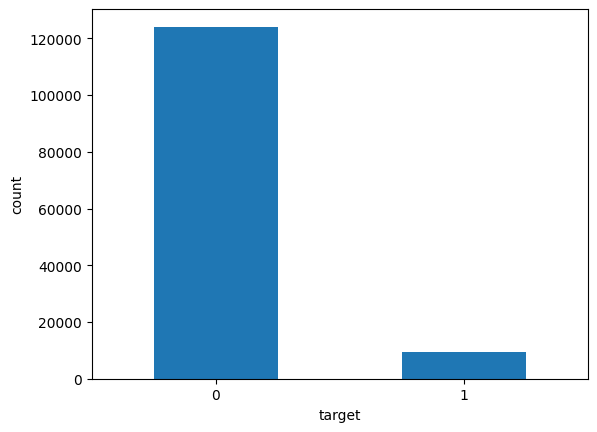

Fold 0:
--> fold train size: (73025, 185)
--> fold valid size: (8640, 185)
--> fold test size: (8640, 185)
  dataset  K  f1_score  precision  recall    TP   FP     TN    FN  \
0   train  0      0.86       0.97    0.77  4563  123  66945  1394   
1   valid  0      0.08       0.06    0.10    49  728   7404   459   
2    test  0      0.15       0.14    0.16    82  485   7651   422   

             Min_date            Max_date train_duration  profit_percent  \
0 2023-01-10 03:55:00 2023-12-29 17:15:00            4.5             NaN   
1 2024-02-09 17:20:00 2024-03-22 17:15:00            4.5         -166.72   
2 2024-03-22 17:20:00 2024-05-03 17:15:00            4.5         -116.83   

   max_dd n_unique_days n_max_daily_sig  
0     NaN          None            None  
1 -156.37            26              98  
2 -131.59            24              75  
Fold 1:
--> fold train size: (90305, 185)
--> fold valid size: (8640, 185)
--> fold test size: (8640, 185)
  dataset  K  f1_score  precision  r

In [14]:
if MANUAL_EXP:
    exp_obj, exp_metadata, artifact_name = main(
        manual = True,
        man_params = man_params[model_type],
        dataset_path = "/kaggle/input/algotrading-project/dataset.parquet",
        C5M_data_path = "/kaggle/input/algotrading-project/",
    )

In [16]:
imp_fe = list(exp_obj.feature_importance[exp_obj.feature_importance.cv<.5].feature_name)
exp_obj.feature_importance[exp_obj.feature_importance.cv<.5].feature_name

224         fe_market_close_USDJPY_London_time
65          fe_market_close_EURUSD_London_time
262           fe_cndl_USDJPY_M1440_HIGH_to_LOW
335    fe_RSTD_USDJPY_M240_CLOSE_W30_cndl_M240
227           fe_ATR_USDJPY_M240_W30_cndl_M240
                        ...                   
390            fe_cndl_XAUUSD_M5_CLOSE_to_OPEN
72             fe_cndl_EURUSD_M5_CLOSE_to_OPEN
392            fe_cndl_XAUUSD_M5_HIGH_to_CLOSE
413            fe_cndl_XAUUSD_M60_CLOSE_to_LOW
74             fe_cndl_EURUSD_M5_HIGH_to_CLOSE
Name: feature_name, Length: 282, dtype: object

In [17]:
def plot_feature_importances_scatter(importance_df, top_n=10, figsize=(8, 6)):
    # Calculate mean importance and sort features
    mean_importance = importance_df['mean_importance']
    sorted_idx = mean_importance.argsort()[::-1]
    top_features = importance_df.iloc[sorted_idx[:top_n]]
    imp_cols = [f for f in importance_df if 'importance_fold' in f]
    # Prepare data for scatter plot
    feature_names = top_features['feature_name']
    importance_values = top_features[imp_cols].values.T  # Transpose for plotting

    # Calculate median importance
    median_importance = top_features['median_importance']

    # Create scatter plot
    fig, ax = plt.subplots(figsize=figsize)
    
    for i, feature in enumerate(feature_names):
        ax.scatter([i] * importance_values.shape[0], importance_values[:, i], 
                   alpha=0.6, label=feature)

    # Plot median line
    ax.plot(range(top_n), median_importance, color='red', linestyle='--', 
            linewidth=2, label='Median')
    
    # Add value labels on the median line
    for i, v in enumerate(median_importance):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

    ax.set_xlabel('Features', fontsize=12)
    ax.set_ylabel('Feature Importance', fontsize=12)
    ax.set_title(f'Top {top_n} Feature Importances Across Folds with Median', fontsize=14)
    ax.set_xticks(range(top_n))
    ax.set_xticklabels(feature_names, rotation=45, ha='right')
#     ax.legend(title='Features', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

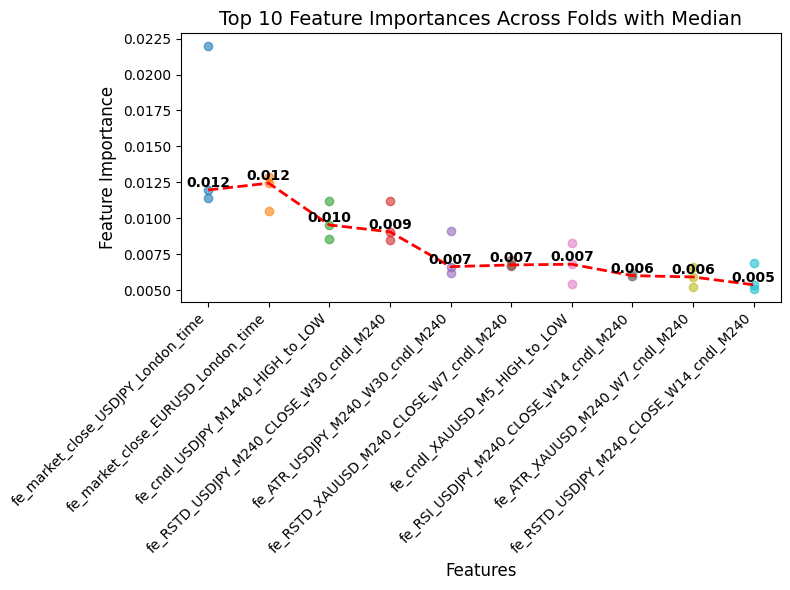

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
plot_feature_importances_scatter(exp_obj.feature_importance)

### Save manual object on W&B as Artifact

In [19]:
if MANUAL_EXP:
    wandb.init(entity = 'alpha-hunters', project = 'algotrading-project')
    obj_artifact = wandb.Artifact(artifact_name, 'manual_experiment', metadata = exp_metadata)
    obj_artifact.add_file(local_path=exp_obj.store_name+'.zip', name=exp_obj.store_name+'.zip')
    wandb.log_artifact(obj_artifact)

In [20]:
if MANUAL_EXP:
    wandb.finish()

## Save imp_features (when we have RANDOM features)

In [ ]:
if MANUAL_EXP:
    upload_imp_features = True
    symbol = man_params[model_type]['target_symbol']
    trade_mode = man_params[model_type]['trade_mode']
    look_ahead = man_params[model_type]['look_ahead']
    take_profit = man_params[model_type]['take_profit']
    stop_loss = man_params[model_type]['stop_loss']

In [ ]:
if MANUAL_EXP and upload_imp_features :
    print('save_imp_features ')
    import pickle as pkl
    the_name = f"df_feature_imp_{trade_mode}_{symbol}_M{look_ahead}_TP{take_profit}_SL{stop_loss}.pkl"
    file = open(the_name, 'wb')
    pkl.dump(exp_obj.feature_importance,file)
    file.close()
    
    imp_artifact_name = artifact_name + '_imp_features'
    wandb.init(entity = 'alpha-hunters', project = 'algotrading-project', job_type="feature_selection")
    imp_artifact = wandb.Artifact(imp_artifact_name, 'feature_selection', metadata = exp_metadata)
    imp_artifact.add_file(local_path = the_name,name = the_name)
    print(f"--> dataset size MB: {imp_artifact.size / 1000000}")
    wandb.log_artifact(imp_artifact)
    wandb.finish()

# 2. Sweep Experiment using W&B

In [11]:
#? https://www.kaggle.com/code/prashant111/a-guide-on-xgboost-hyperparameters-tuning/notebook
sweep_configs = {}
sweep_configs['RF'] = {
    "method": "grid",
#     "metric": {"name": "class 1 f0.03_score_train", "goal": "maximize"},
#     'description':description,
    "parameters": {
        'model_name' : {"values": ['RF']},
        
        'target_symbol' : {"values": ['EURUSD']},
        'trade_mode' : {"values": ['long']},
        "trg_look_ahead": {"values": [120]},
        "trg_take_profit": {"values": [12]},
        "trg_stop_loss": {"values": [5]},
        
        "strg_look_ahead": {"values": [120]},
        "strg_take_profit": {"values": [12]},
        "strg_stop_loss": {"values": [5]},
        
        'save_model_mode' : {"values": ['last_train_size']}, # None, 'sample_train_size', 'last_train_size', 'all_data',
        'imp_features' : {"values": [None]},  #  can be set to imp_features or None
        'n_rand_features': {"values": [None]},
        "early_stopping_rounds" :{"values": [None]},
        "n_splits" : {"values": [17]},
        "max_train_size": {"values": [500*288]},
        'test_size' : {"values": [30*288]},
        'train_test_gap' : {"values": [0]},

        
        'n_estimators' : {"values": [200]},
        'max_depth': {"values": [5,12]},
        'max_features' : {"values": [30, 50,80]},
        'max_samples' : {"values": [0.2,0.3,0.4]},
        'class_weight':{'values':[0.13,0.15, 0.18, 0.23]},
        'n_jobs': {"values": [-1]},
        'random_state' : {"values": [42]},
                       
#         "objective": {"values": ["binary:logistic"]},
        
#         "max_depth": {"values": [2, 5, 8, 15, 20, 30]},
#         "learning_rate": {"distribution": "uniform", "min": 0.005, "max": 0.01},
#         "n_estimators": {"distribution": "int_uniform", "min": 50, "max": 300},
#         "min_child_weight": {"distribution": "uniform", "min": 0, "max": 1}, # Used to control over-fitting.
#         "subsample": {"distribution": "uniform", "min": 0.3, "max": 0.5 } ,#Lower values make the algorithm more conservative and prevents overfitting but too small values might lead to under-fitting.

        
#         "early_stopping_rounds" :{"distribution": "int_uniform", "min": 5, "max": 150},
#         "early_stopping_rounds" :{"values": [40,200]},
#         "gamma": {"distribution": "uniform", "min": 0, "max": 15}, #? float
#         "max_delta_step": {"distribution": "uniform", "min": 0, "max": 15}, #?float
#         "colsample_bytree": {"distribution": "uniform", "min": 0.5, "max": 0.75}, 
#         "reg_lambda": {"distribution": "uniform", "min": 0, "max": 10},
#         "reg_alpha": {"distribution": "uniform", "min": 0, "max": 10},   
#         "train_data_precent": {"distribution": "uniform", "min": 0, "max": 0.98},
#         "train_data_precent": {"distribution": "uniform", "min": 0.5, "max": 0.95},
    },
}

In [13]:
sweep_configs['XGB'] = {
    "method": "grid",
    
    "parameters": {
        'model_name' : {"values": ['XGB']},
        
        'target_symbol' : {"values": ['USDJPY']}, # ["EURUSD","USDCAD","USDJPY","EURJPY","GBPUSD","XAUUSD"]
        'trade_mode' : {"values": ['long']}, # "long", "short"
        "trg_look_ahead": {"values": [300]},
        "trg_take_profit": {"values": [35]},
        "trg_stop_loss": {"values": [5]},
        
        "strg_look_ahead": {"values": [480]},
        "strg_take_profit": {"values": [40]},
        "strg_stop_loss": {"values": [15]},
                
        'n_rand_features': {"values": [None]}, # None or Number
        'save_model_mode' : {"values": [None]}, # None, 'sample_train_size', 'last_train_size', 'all_data',

        "early_stopping_rounds" :{"values": [None]}, #None or Number
        'n_splits' : {"values":[3]},
        'max_train_size' : {"values":[400*288,300*288]},
        'test_size' : {"values":[30*288]},
        'train_test_gap' : {"values": [0]},
        
        "objective": {"values": ["binary:logistic"]},
        "max_depth": {"values": [4,5]},
        "learning_rate": {"values": [0.1,0.01,0.05]},
        'tree_method': {"values": [None]}, #'hist', None
        'device' : {"values": ["cpu"]}, # 'cuda', None
#         "learning_rate": {"distribution": "log_uniform", "min": 1e-5, "max": 5e-1},
        "n_estimators": {"values": [100]},
#         "early_stopping_rounds" :{"distribution": "int_uniform", "min": 5, "max": 150},
#         "early_stopping_rounds" :{"values": [40,200]},
#         "gamma": {"distribution": "uniform", "min": 0, "max": 15}, #? float
        "min_child_weight": {"values": [1]}, # Used to control over-fitting.
#         "max_delta_step": {"distribution": "uniform", "min": 0, "max": 15}, #?float
        "subsample": {"values": [0.3,0.5,0.8]},#Lower values make the algorithm more conservative and prevents overfitting but too small values might lead to under-fitting.
        "colsample_bytree": {"values": [0.5,0.8]},
        "reg_lambda": {"values": [0,0.02,0.1]},
#         "reg_alpha": {"distribution": "uniform", "min": 0, "max": 10},
        "scale_pos_weight" : {"values": [1]},#[1,0.95,1.1]
        'random_state': {"values":[42]},
        },
}

In [ ]:
%%time

sweep_id = wandb.sweep(
    sweep_configs[model_type],
    entity = 'alpha-hunters',
    project = 'algotrading-project'
)

#!!!!!!!!!!!! SWEEP ID !!!!!!!!!!!!!!!!!
wandb.agent(sweep_id = sweep_id, function = main, entity = 'alpha-hunters',project = 'algotrading-project')
wandb.finish()

Create sweep with ID: wviokop8
Sweep URL: https://wandb.ai/alpha-hunters/algotrading-project/sweeps/wviokop8


wandb: Agent Starting Run: 4h7mieuq with config:
wandb: 	colsample_bytree: 0.5
wandb: 	device: cpu
wandb: 	early_stopping_rounds: None
wandb: 	learning_rate: 0.1
wandb: 	max_depth: 4
wandb: 	max_train_size: 115200
wandb: 	min_child_weight: 1
wandb: 	model_name: XGB
wandb: 	n_estimators: 100
wandb: 	n_rand_features: None
wandb: 	n_splits: 3
wandb: 	objective: binary:logistic
wandb: 	random_state: 42
wandb: 	reg_lambda: 0
wandb: 	save_model_mode: None
wandb: 	scale_pos_weight: 1
wandb: 	strg_look_ahead: 480
wandb: 	strg_stop_loss: 15
wandb: 	strg_take_profit: 40
wandb: 	subsample: 0.3
wandb: 	target_symbol: USDJPY
wandb: 	test_size: 8640
wandb: 	trade_mode: long
wandb: 	train_test_gap: 0
wandb: 	tree_method: None
wandb: 	trg_look_ahead: 300
wandb: 	trg_stop_loss: 5
wandb: 	trg_take_profit: 35


Final Parameters of the Model: {'colsample_bytree': 0.5, 'device': 'cpu', 'early_stopping_rounds': None, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 100, 'objective': 'binary:logistic', 'random_state': 42, 'reg_lambda': 0, 'scale_pos_weight': 1, 'subsample': 0.3, 'tree_method': None}
Len all columns in dataframe is 498
Len read columns is 498
Calculating target --->
---> Target trg_clf_long_USDJPY_M300_TP35_SL5 has been generated in 2.87 seconds
df shape:  (130069, 499)
--> df final shape: (130069, 498)
--> df min_time: 2023-01-10 03:55:00 | df max_time: 2024-10-02 18:55:00
--> number of unique days: 130069
Fold 0:
--> fold train size: (78229, 503)
--> fold valid size: (8640, 503)
--> fold test size: (8640, 503)
  dataset  K  f1_score  precision  recall   TP  FP     TN    FN  \
0   train  0      0.10       0.92    0.05  316  28  72239  5646   
1   valid  0      0.01       0.07    0.00    1  13   8277   349   
2    test  0      0.01       0.10    0.01   

f1_score_ex0_test,▁
f1_score_ex0_train,▁
f1_score_ex0_valid,▁
f1_score_ex0_valid&test,▁
max_dd_mean_test,▁
max_dd_mean_valid,▁
max_dd_mean_valid&test,▁
max_dd_median_test,▁
max_dd_median_valid,▁
max_dd_median_valid&test,▁
max_dd_min_test,▁


wandb: Agent Starting Run: w2sapyly with config:
wandb: 	colsample_bytree: 0.5
wandb: 	device: cpu
wandb: 	early_stopping_rounds: None
wandb: 	learning_rate: 0.1
wandb: 	max_depth: 4
wandb: 	max_train_size: 115200
wandb: 	min_child_weight: 1
wandb: 	model_name: XGB
wandb: 	n_estimators: 100
wandb: 	n_rand_features: None
wandb: 	n_splits: 3
wandb: 	objective: binary:logistic
wandb: 	random_state: 42
wandb: 	reg_lambda: 0
wandb: 	save_model_mode: None
wandb: 	scale_pos_weight: 1
wandb: 	strg_look_ahead: 480
wandb: 	strg_stop_loss: 15
wandb: 	strg_take_profit: 40
wandb: 	subsample: 0.5
wandb: 	target_symbol: USDJPY
wandb: 	test_size: 8640
wandb: 	trade_mode: long
wandb: 	train_test_gap: 0
wandb: 	tree_method: None
wandb: 	trg_look_ahead: 300
wandb: 	trg_stop_loss: 5
wandb: 	trg_take_profit: 35


...

/kaggle/working/ML-Algotrading-Project/utils/evaluation_utils.py:40: RuntimeWarning: invalid value encountered in scalar divide
  f"precision_total_{set_name}": evals_df.TP.sum() / (evals_df.TP.sum() + evals_df.FP.sum()),
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/kaggle/working/ML-Algotrading-Project/utils/evaluation_utils.py:40: RuntimeWarning: invalid value encountered in scalar divide
  f"precision_total_{set_name}": evals_df.TP.sum() / (evals_df.TP.sum() + evals_df.FP.sum()),
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/kaggle/working/ML-Algotrading-Project/utils/evaluation_utils.py:40: RuntimeWarning: invalid value encountered in scalar divide
  f"precision_total_{set_name}": evals_df.TP.sum() / (evals_df.TP.sum() + evals_df.FP.sum()),
/opt

object stored as pickle: XGB_long_USDJPY_M300_TP35_SL5_prof0.00_max_dd0.00_median_sig0.00_date2024-10-17_12:41.pkl
object pickle stored zipped: XGB_long_USDJPY_M300_TP35_SL5_prof0.00_max_dd0.00_median_sig0.00_date2024-10-17_12:41.pkl


f1_score_ex0_train,▁
max_dd_mean_test,▁
max_dd_mean_valid,▁
max_dd_mean_valid&test,▁
max_dd_median_test,▁
max_dd_median_valid,▁
max_dd_median_valid&test,▁
max_dd_min_test,▁
max_dd_min_valid,▁
max_dd_min_valid&test,▁
max_dd_test,▁


wandb: Agent Starting Run: uaokia6x with config:
wandb: 	colsample_bytree: 0.5
wandb: 	device: cpu
wandb: 	early_stopping_rounds: None
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 4
wandb: 	max_train_size: 86400
wandb: 	min_child_weight: 1
wandb: 	model_name: XGB
wandb: 	n_estimators: 100
wandb: 	n_rand_features: None
wandb: 	n_splits: 3
wandb: 	objective: binary:logistic
wandb: 	random_state: 42
wandb: 	reg_lambda: 0
wandb: 	save_model_mode: None
wandb: 	scale_pos_weight: 1
wandb: 	strg_look_ahead: 480
wandb: 	strg_stop_loss: 15
wandb: 	strg_take_profit: 40
wandb: 	subsample: 0.5
wandb: 	target_symbol: USDJPY
wandb: 	test_size: 8640
wandb: 	trade_mode: long
wandb: 	train_test_gap: 0
wandb: 	tree_method: None
wandb: 	trg_look_ahead: 300
wandb: 	trg_stop_loss: 5
wandb: 	trg_take_profit: 35


Final Parameters of the Model: {'colsample_bytree': 0.5, 'device': 'cpu', 'early_stopping_rounds': None, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 100, 'objective': 'binary:logistic', 'random_state': 42, 'reg_lambda': 0, 'scale_pos_weight': 1, 'subsample': 0.5, 'tree_method': None}
Len all columns in dataframe is 498
Len read columns is 498
Calculating target --->
---> Target trg_clf_long_USDJPY_M300_TP35_SL5 has been generated in 2.89 seconds
df shape:  (130069, 499)
--> df final shape: (130069, 498)
--> df min_time: 2023-01-10 03:55:00 | df max_time: 2024-10-02 18:55:00
--> number of unique days: 130069
Fold 0:
--> fold train size: (78229, 503)
--> fold valid size: (8640, 503)
--> fold test size: (8640, 503)


In [ ]:
# Import necessary libraries
import wandb

# The sweep ID should be the same as the one you started with
sweep_id = 'wviokop8'

# Resume the sweep
wandb.agent(sweep_id=sweep_id, function=main, entity='alpha-hunters', project='algotrading-project')

# Finish the sweep
wandb.finish()

wandb: Agent Starting Run: tbbp7xqa with config:
wandb: 	colsample_bytree: 0.8
wandb: 	device: cpu
wandb: 	early_stopping_rounds: None
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 4
wandb: 	max_train_size: 86400
wandb: 	min_child_weight: 1
wandb: 	model_name: XGB
wandb: 	n_estimators: 100
wandb: 	n_rand_features: None
wandb: 	n_splits: 3
wandb: 	objective: binary:logistic
wandb: 	random_state: 42
wandb: 	reg_lambda: 0
wandb: 	save_model_mode: None
wandb: 	scale_pos_weight: 1
wandb: 	strg_look_ahead: 480
wandb: 	strg_stop_loss: 15
wandb: 	strg_take_profit: 40
wandb: 	subsample: 0.3
wandb: 	target_symbol: USDJPY
wandb: 	test_size: 8640
wandb: 	trade_mode: long
wandb: 	train_test_gap: 0
wandb: 	tree_method: None
wandb: 	trg_look_ahead: 300
wandb: 	trg_stop_loss: 5
wandb: 	trg_take_profit: 35


Final Parameters of the Model: {'colsample_bytree': 0.8, 'device': 'cpu', 'early_stopping_rounds': None, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 100, 'objective': 'binary:logistic', 'random_state': 42, 'reg_lambda': 0, 'scale_pos_weight': 1, 'subsample': 0.3, 'tree_method': None}
Len all columns in dataframe is 498
Len read columns is 498
Calculating target --->
---> Target trg_clf_long_USDJPY_M300_TP35_SL5 has been generated in 3.00 seconds
df shape:  (130069, 499)
--> df final shape: (130069, 498)
--> df min_time: 2023-01-10 03:55:00 | df max_time: 2024-10-02 18:55:00
--> number of unique days: 130069
Fold 0:
--> fold train size: (78229, 503)
--> fold valid size: (8640, 503)
--> fold test size: (8640, 503)
  dataset  K  f1_score  precision  recall  TP  FP     TN    FN  \
0   train  0      0.02        1.0    0.01  65   0  72267  5897   
1   valid  0      0.00        0.0    0.00   0   0   8290   350   
2    test  0      0.00        0.0    0.00   0 

/kaggle/working/ML-Algotrading-Project/utils/evaluation_utils.py:40: RuntimeWarning: invalid value encountered in scalar divide
  f"precision_total_{set_name}": evals_df.TP.sum() / (evals_df.TP.sum() + evals_df.FP.sum()),
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


object stored as pickle: XGB_long_USDJPY_M300_TP35_SL5_prof0.00_max_dd0.00_median_sig0.00_date2024-10-17_20:52.pkl
object pickle stored zipped: XGB_long_USDJPY_M300_TP35_SL5_prof0.00_max_dd0.00_median_sig0.00_date2024-10-17_20:52.pkl


f1_score_ex0_train,▁
f1_score_ex0_valid,▁
f1_score_ex0_valid&test,▁
max_dd_mean_test,▁
max_dd_mean_valid,▁
max_dd_mean_valid&test,▁
max_dd_median_test,▁
max_dd_median_valid,▁
max_dd_median_valid&test,▁
max_dd_min_test,▁
max_dd_min_valid,▁


...

/kaggle/working/ML-Algotrading-Project/utils/evaluation_utils.py:40: RuntimeWarning: invalid value encountered in scalar divide
  f"precision_total_{set_name}": evals_df.TP.sum() / (evals_df.TP.sum() + evals_df.FP.sum()),
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


object stored as pickle: XGB_long_USDJPY_M300_TP35_SL5_prof0.00_max_dd0.00_median_sig0.00_date2024-10-17_21:28.pkl
object pickle stored zipped: XGB_long_USDJPY_M300_TP35_SL5_prof0.00_max_dd0.00_median_sig0.00_date2024-10-17_21:28.pkl


f1_score_ex0_train,▁
f1_score_ex0_valid,▁
f1_score_ex0_valid&test,▁
max_dd_mean_test,▁
max_dd_mean_valid,▁
max_dd_mean_valid&test,▁
max_dd_median_test,▁
max_dd_median_valid,▁
max_dd_median_valid&test,▁
max_dd_min_test,▁
max_dd_min_valid,▁


wandb: Agent Starting Run: 1pejuzvi with config:
wandb: 	colsample_bytree: 0.8
wandb: 	device: cpu
wandb: 	early_stopping_rounds: None
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 5
wandb: 	max_train_size: 86400
wandb: 	min_child_weight: 1
wandb: 	model_name: XGB
wandb: 	n_estimators: 100
wandb: 	n_rand_features: None
wandb: 	n_splits: 3
wandb: 	objective: binary:logistic
wandb: 	random_state: 42
wandb: 	reg_lambda: 0
wandb: 	save_model_mode: None
wandb: 	scale_pos_weight: 1
wandb: 	strg_look_ahead: 480
wandb: 	strg_stop_loss: 15
wandb: 	strg_take_profit: 40
wandb: 	subsample: 0.5
wandb: 	target_symbol: USDJPY
wandb: 	test_size: 8640
wandb: 	trade_mode: long
wandb: 	train_test_gap: 0
wandb: 	tree_method: None
wandb: 	trg_look_ahead: 300
wandb: 	trg_stop_loss: 5
wandb: 	trg_take_profit: 35


Final Parameters of the Model: {'colsample_bytree': 0.8, 'device': 'cpu', 'early_stopping_rounds': None, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 100, 'objective': 'binary:logistic', 'random_state': 42, 'reg_lambda': 0, 'scale_pos_weight': 1, 'subsample': 0.5, 'tree_method': None}
Len all columns in dataframe is 498
Len read columns is 498
Calculating target --->
---> Target trg_clf_long_USDJPY_M300_TP35_SL5 has been generated in 2.91 seconds
df shape:  (130069, 499)
--> df final shape: (130069, 498)
--> df min_time: 2023-01-10 03:55:00 | df max_time: 2024-10-02 18:55:00
--> number of unique days: 130069
Fold 0:
--> fold train size: (78229, 503)
--> fold valid size: (8640, 503)
--> fold test size: (8640, 503)


In [ ]:
#STOP SWEEP
if not MANUAL_EXP:
    print('Finishing The SWEEP ...')
    print(f'{1/0}')

# Filter models from W&B

In [ ]:
runs_filter = {'path' : "fitechivo/tradeset_models",# /artifacts/experiment/trg_clf_long_EURUSD_M240_TP25_SL10
               "order": "+summary_metrics.profit_percent_test",
    'filters': {"$and": [  
#                         {"state":'finished'},
                        {"createdAt":{ '$gte': '2024-06-01' }},
                        {"sweep":'jmw8zpy9'},
        
                        ########### GENERAL CONFIG #############
                        {"config.target_symbol":'USDJPY'}, 
                        {"config.trade_mode": 'long'},
#                         {"config.look_ahead": 480},
#                         {"config.strg_take_profit": 40},
#                         {"config.strg_stop_loss": 15},
                        {"config.model_name":'XGB'},
#                         ########### MODEL CONFIG #############
#                         {"config.max_depth": 3 },
#                         {"config.n_estimators": { "$gte": 100 } },
#                         {"config.learning_rate": { "$lt": 1 }},
#                         {"config.random_state": 42 },
                        
                        ########### MODEL METRICS #############
                        {"summary_metrics.profit_percent_test" : { "$gte": 10}},
                        {"summary_metrics.profit_percent_val" : { "$gte": 10}},
                        
                        {"summary_metrics.profit_percent_median_test" : { "$gte": 5}},
                        {"summary_metrics.profit_percent_median_valid" : { "$gte": 5}},
        
                        {"summary_metrics.max_dd_min_test" : { "$gte":-40}},
                        {"summary_metrics.max_dd_min_valid" : { "$gte":-40}},

                        {"summary_metrics.max_dd_test" : { "$gte":-40}},
                        {"summary_metrics.max_dd_val" : { "$gte":-40}},

        

                                ]
            }
}
runs=api.runs(**runs_filter)
print(len(runs))

In [ ]:
# wandb.finish()

In [ ]:
import shutil
import os
if os.path.isdir("/kaggle/working/artifacts"):
    shutil.rmtree("/kaggle/working/artifacts")
meta_datas=fetch_artifacts(runs_filter)

In [ ]:
objects = read_tracker_objects("/kaggle/working/artifacts")

In [ ]:
# objects['XGB_long_USDJPY_M300_TP35_SL5_prof531.41_max_dd-56.54_median_sig9.00_date2024-07-08_21:24']['obj'].evals

## Selected Models' Config

In [ ]:
import pandas as pd
for i,k in enumerate(objects):
    if i == 0:
        df_config = pd.DataFrame(objects[k]['obj'].config, index = [0])
#         display(df_config)
    else:
        df_config = pd.concat([df_config,pd.DataFrame(objects[k]['obj'].config, index = [0])])
# df_config[['colsample_bytree',
#        'learning_rate', 'trg_look_ahead', 'max_depth', 'max_train_size',
#        'min_child_weight', 'model_name', 'n_estimators', 'save_model_mode', 'scale_pos_weight',
#        'subsample', 'trg_take_profit', 'target_symbol', 'tree_method']]
df_config

## Feature Importance

In [ ]:
for i,k in enumerate(objects):
    if i == 0:
        df_imp = objects[k]['obj'].feature_importance
        df_imp.rename(columns = {'importances': f'importances_{i}'}, inplace =True)
    else:
        
        df_imp = df_imp.merge(objects[k]['obj'].feature_importance.rename(columns = {'importances': f'importances_{i}'}),
                             on = 'feature_name')
imp_cols = [f for f in df_imp.columns if 'importances_' in f]
df_imp['imp_mean'] =df_imp[imp_cols].mean(axis = 1)
df_imp.sort_values('imp_mean', ascending = False)[:30]

## Models' Correlation

In [ ]:
import pandas as pd
def cal_corr_tar1_predictions(objects):
    '''Calculate corrilation between models Just for target==1'''
    corr_ls=[]
    for i,n in enumerate(objects):

        val_predictions = objects[n]['obj'].val_predictions
        val_predictions=val_predictions[val_predictions.target==1][['pred_as_val','target']].replace(0, -1)
        corr_ls.append((n,val_predictions))
    print("Total_model_count:", len(corr_ls))
        
    from sklearn.metrics import matthews_corrcoef
    corr_dict={}
    for i in range(0,len(corr_ls)):
        for j in range(i+1,len(corr_ls)):
            corr_dict[(corr_ls[i][0],corr_ls[j][0])]=matthews_corrcoef(corr_ls[i][1]['pred_as_val'], corr_ls[j][1]['pred_as_val'])
        
        
    corr_df=pd.DataFrame([k + (v,) for k, v in corr_dict.items()], columns=['model1', 'model2', 'M_corr'])
    print('combination checked:', corr_df.shape[0])
    corr_df.hist('M_corr')
    return corr_df

corr_df=cal_corr_tar1_predictions(objects)

In [ ]:
# corr_df[corr_df.M_corr<0.7]
corr_df